# 📊 Layoff Dataset Analysis — Final Notebook

Generated on 2026-03-20

## 1. Objective
Analyze layoffs across companies to understand:
- Key drivers of layoffs
- Role of AI
- Market reaction
- Geographic patterns


## 2. Load Data

In [1]:
import pandas as pd

# Update path if needed
df = pd.read_csv('global_ai_tech_layoffs_2020_2026.csv')

df.head()


,event_id,company,industry,hq_country,hq_city,continent,founded_year,company_size_est,company_status,date_announced,...,quarter,number_laid_off,percentage_of_workforce,departments_affected,primary_reason,impact_scope,severance_info,source,stock_price_change_1wk_pct,is_ai_related_layoff
0,LO-1034,Swiggy,Food Delivery,India,Bangalore,Asia,2014,6000,Private,2020-01-04,...,Q1,722,12.0,HR / People; Legal; Product,Post-Pandemic Overhiring Correction,Global,Varies by region,News Report - The Verge,NaN,False
1,LO-1020,Oracle,Enterprise Software,United States,Austin,North America,1977,164000,Public,2020-01-06,...,Q1,6189,3.8,Legal; Business Development; Data Science / AI...,Investor Pressure,Global,6 months base salary,News Report - Bloomberg,-1.30,False
2,LO-1051,Tesla,Electric Vehicles / AI,United States,Austin,North America,2003,140000,Public,2020-01-08,...,Q1,9512,6.8,Operations,Product Shutdown,Multiple Regions,6 months base salary,News Report - CNBC,-3.89,False
3,LO-1063,Anthropic,Artificial Intelligence,United States,San Francisco,North America,2021,1500,Private,2020-01-09,...,Q1,132,8.8,Marketing; Sales; Research; Customer Support,AI Automation Replacing Roles,United States,Varies by region,Company Press Release,NaN,True
4,LO-1139,Alibaba,E-Commerce / Cloud,China,Hangzhou,Asia,1999,220000,Public,2020-01-11,...,Q1,16245,7.4,Recruiting; Supply Chain; Legal; Engineering,Merger / Acquisition,China,4 weeks base salary,News Report - TechCrunch,-5.16,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   event_id                    1850 non-null   str    
 1   company                     1850 non-null   str    
 2   industry                    1850 non-null   str    
 3   hq_country                  1850 non-null   str    
 4   hq_city                     1850 non-null   str    
 5   continent                   1850 non-null   str    
 6   founded_year                1850 non-null   int64  
 7   company_size_est            1850 non-null   int64  
 8   company_status              1850 non-null   str    
 9   date_announced              1850 non-null   str    
 10  year                        1850 non-null   int64  
 11  month                       1850 non-null   int64  
 12  quarter                     1850 non-null   str    
 13  number_laid_off             1850 non-null   

## 3. Handle Missing Data

In [3]:
# Flag missing stock data
df['stock_missing_flag'] = df['stock_price_change_1wk_pct'].isna().astype(int)

# Fill missing stock values
df['stock_price_change_1wk_pct'] = df['stock_price_change_1wk_pct'].fillna(0)


## 4. Data Type Conversion

In [4]:
df['is_ai_related_layoff'] = df['is_ai_related_layoff'].astype(int)


## 5. Encoding Categorical Variables

In [6]:
from sklearn.preprocessing import LabelEncoder

# Country encoding
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['hq_country'])

# Company status
df['company_status_encoded'] = df['company_status'].map({'Private': 0, 'Public': 1})

# Continent encoding
le_continent = LabelEncoder()
df['continent_encoded'] = le_continent.fit_transform(df['continent'])


## 6. Feature Engineering

In [7]:
df['layoff_intensity'] = df['number_laid_off'] / df['company_size_est']


## 7. Correlation Heatmap

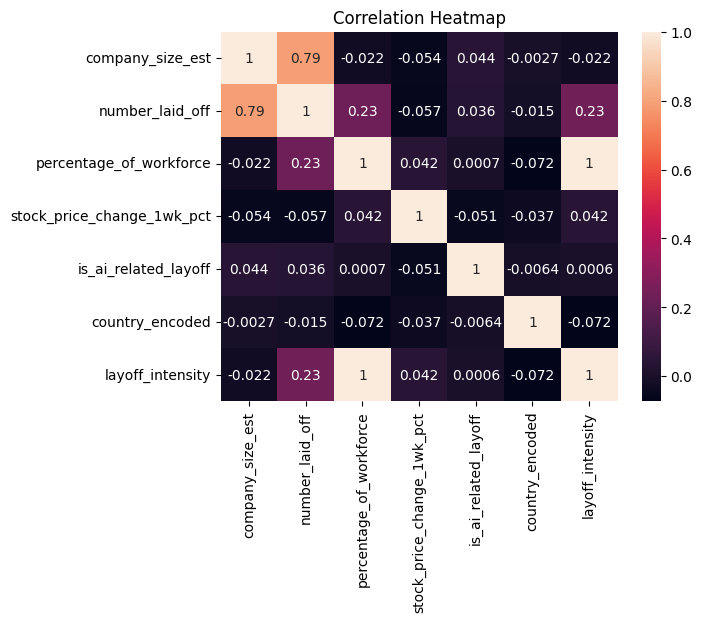

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'company_size_est',
    'number_laid_off',
    'percentage_of_workforce',
    'stock_price_change_1wk_pct',
    'is_ai_related_layoff',
    'country_encoded',
    'layoff_intensity'
]

corr_matrix = df[features].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()


## 8. Scale Effect Visualization

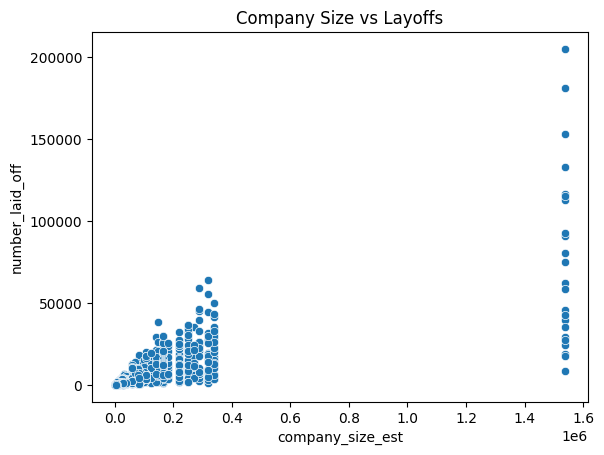

In [9]:
sns.scatterplot(data=df, x='company_size_est', y='number_laid_off')
plt.title("Company Size vs Layoffs")
plt.show()


## 9. AI vs Non-AI Layoffs

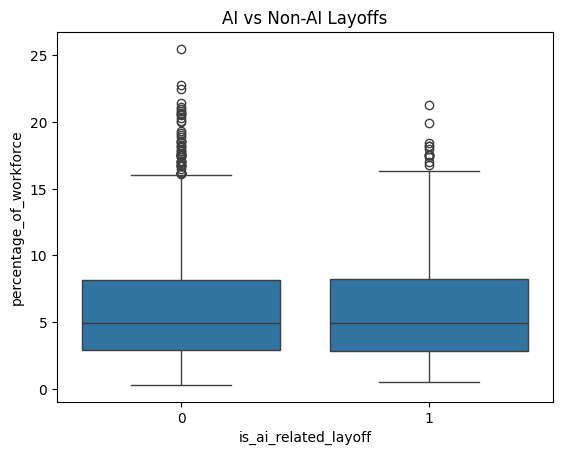

In [10]:
sns.boxplot(data=df, x='is_ai_related_layoff', y='percentage_of_workforce')
plt.title("AI vs Non-AI Layoffs")
plt.show()


## 10. Key Insights

### 1. Scale Effect
Larger companies lay off more employees in absolute terms.

### 2. Severity vs Scale
Percentage of workforce is a better indicator of impact.

### 3. AI Impact
AI layoffs are more targeted and structural.

### 4. Market Reaction
Layoffs do not strongly influence stock price.

### 5. Geography
Layoffs are driven by global trends rather than country-specific factors.
